<a href="https://colab.research.google.com/github/therealcaesar-si/EMSC2010-W10-L1-u7567593/blob/main/EMSC2010_W10_L1_NB1_u7567593.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB1

In this notebook we'll plot the Cave Creek water runoff data. Importantly, the plotting function allows you to interact with the plot. You can click data points and they will be recorded. We can then convert that information into ```numpy``` arrays.

We need to import several libraries that we haven't used before. These will enable us to interact with the data plot.

In [1]:
# Enable custom widget support in Google Colab's output cell
from google.colab import output
output.enable_custom_widget_manager()

# Plotly: interactive, browser-based charting library
import plotly.graph_objects as go

# ipywidgets: interactive UI widgets for Jupyter/Colab notebooks (sliders, dropdowns, etc.)
import ipywidgets as widgets

# IPython display utilities:
# - display: renders rich output (widgets, HTML, images) in notebook cells
# - clear_output: clears the current cell's output (useful for dynamic updates)
from IPython.display import display, clear_output

import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

Define the data file and read in using ```pandas```. Don't forget to drag the data file (available in the GitHub repository) into the Colab file space.

In [2]:
file = 'cave-creek.xlsx' #define the name of the data file
df = pd.read_excel(file) #read the file into a dataframe
df.head() #show the dataframe header

,Month,Runoff [inches]
0,0,2
1,1,5
2,2,19
3,3,240
4,4,86


As a first step we'll plot the data. Consider which points you will select to define the events.

(0.0, 225.75)

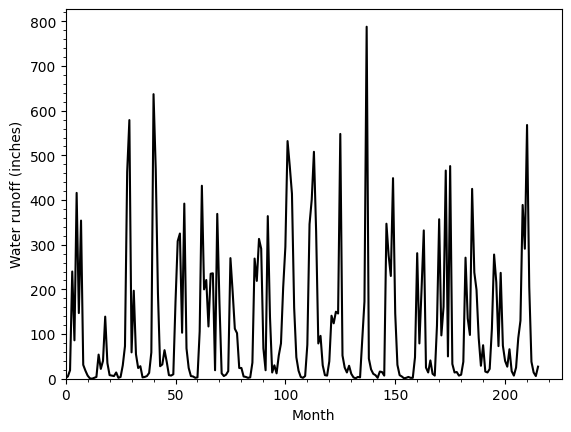

In [3]:
month = df['Month'].values #get the month data as a numpy array
runoff = df['Runoff [inches]'].values #get the runoff data as a numpy array
plt.plot(month,runoff,'k') #plot the data
plt.xlabel('Month') #label the x-axis
plt.ylabel('Water runoff (inches)') #label the y-axis
plt.minorticks_on() #add minor ticks to the plot
plt.ylim(bottom=0) #limit the y-axis
plt.xlim(left=0) #limit the x-axis

The code in the next cell is a function that will plot the data and allow you to select data points by clicking on them. By running the cell the function will be stored in Python and ready to use. You don't need to worry about the code in the function (I used Gemini to write the code).

In [4]:
def interactive_point_selector(x_data, y_data):
    """
    Displays an interactive scatter plot where users can click on points to select them.
    The selected points are stored in the global 'last_selected_points_result' list
    when the 'Done Selecting Points' button is clicked.

    Args:
        x_data (list or array): The x-coordinates of the points to plot.
        y_data (list or array): The y-coordinates of the points to plot.
    """
    global last_selected_points_result
    last_selected_points_result = [] # Reset for each new call to the function

    f = go.FigureWidget([go.Scatter(x=x_data, y=y_data, mode='lines')])
    scatter = f.data[0]

    # Output widget to display status messages and final results
    output_area = widgets.Output()

    def update_point(trace, points, selector):
        with output_area:
            # clear_output(wait=True) # Optional: uncomment to clear previous messages on each click
            for i in points.point_inds:
                x_val = trace.x[i]
                y_val = trace.y[i]
                last_selected_points_result.append((x_val, y_val))
                print(f"Point Saved: x={x_val}, y={y_val}")

    scatter.on_click(update_point)

    done_button = widgets.Button(description="Done Selecting Points")

    def on_done_button_click(b):
        with output_area:
            clear_output()
            print("--- Selection Complete ---")
            print("\nTo process these points, run the next cell.")

    done_button.on_click(on_done_button_click)

    display(widgets.VBox([f, done_button, output_area]))

We'll now use the function defined above to plot the data. You can then click on the data points you would like to use to define the events.

When you have clicked all the points you need, click the 'Done Selecting Points' button.

In [5]:
last_selected_points_result = [] #create an array to store the results
interactive_point_selector(month,runoff) #call the function with the data

    'data': [{'mode': 'lines',
              'type': 'scatter',
              'u…

In [6]:
# After interacting with the plot and clicking 'Done Selecting Points',
# the selected points will be in 'last_selected_points_result'.
# Now convert them to NumPy arrays.

if last_selected_points_result:
    x_selected = np.array([p[0] for p in last_selected_points_result])
    y_selected = np.array([p[1] for p in last_selected_points_result])

else:
    print("No points were selected, or the 'Done Selecting Points' button was not clicked.")

We've recorded both the $x$ and $y$ values of the points. In terms of event spacing we're interested in the gaps between the x-values (i.e., the difference in months between succesive events).

We can find the difference between succesive values in an array using the ```np.diff``` function. To do this we need to make sure that the time points are in the correct order. For example, if you click on the points out of order, we need to sort them into an ascending sequence.

We'll then find the mean of the differences to find the average event spacing.

In [7]:
x_selected = np.sort(x_selected) #sort values into ascending order
x_diff = np.diff(x_selected) #differences in the x-values
print('Mean event spacing is {:.1f} months'.format(np.mean(x_diff))) #print the result on screen

Mean event spacing is 10.6 months


Now that you have a numerical result, what is your interpretation?